<a href="https://colab.research.google.com/github/shuangquan-li-con/SwiftCart-Logistics-Analysis/blob/main/SwiftCart_Logistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0,size=150)
driver_tips = np.concatenate([zeros,tips])

In [ ]:
np.random.seed(42)
n_boot = 10000
boot_medians = np.empty(n_boot)
n = len(driver_tips)
for i in range(n_boot):
  sample_indices = np.random.choice(n,size=n,replace=True)
  bootstrap_sample = driver_tips[sample_indices]
  boot_medians[i] = np.median(bootstrap_sample)
ci_lower,ci_upper = np.percentile(boot_medians,[2.5,97.5])
print(np.median(driver_tips))
print((ci_lower,ci_upper))


0.7553316913699188
(np.float64(0.2642554369019624), np.float64(1.3635639228066991))


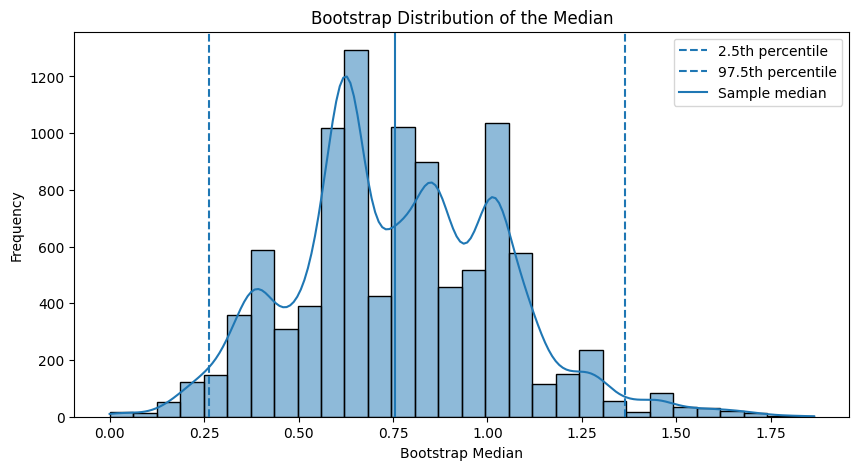

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(boot_medians,bins=30,kde=True)
plt.axvline(ci_lower,linestyle='--',label='2.5th percentile')
plt.axvline(ci_upper,linestyle='--',label='97.5th percentile')
plt.axvline(np.median(driver_tips),linestyle='-',label='Sample median')
plt.title("Bootstrap Distribution of the Median")
plt.xlabel("Bootstrap Median")
plt.ylabel("Frequency")
plt.legend()
plt.show()

According to this graph, we can see that this intercal is asymmetric. The raw data is highly right-skewed and zero-inflated,moreover, the confidence interval is data-driven. Thus, it is asymmetric, which better reflects the real structure of the tip data.

In [ ]:
np.random.seed(42)
control = np.random.normal(loc=35,scale=5,size=500)
treatment = np.random.lognormal(mean=3.4,sigma=0.4,size=500)
observed_diff = np.mean(control) - np.mean(treatment)
print(observed_diff)

2.2649821306257394


In [ ]:
np.random.seed(42)
combined = np.concatenate([control,treatment])
n_perm = 5000
perm_diffs = np.empty(n_perm)
n_control = len(control)
for i in range(n_perm):
  shuffled = np.random.permutation(combined)
  pseudo_control = shuffled[:n_control]
  pseudo_treatment = shuffled[n_control:]
  perm_diffs[i] = np.mean(pseudo_control) - np.mean(pseudo_treatment)
p_value = np.mean(np.abs(perm_diffs)>=np.abs(observed_diff))
print(observed_diff)
print(p_value)

2.2649821306257394
0.0004


In [ ]:
df = pd.read_csv("/content/swiftcart_loyalty.csv")
print(df.head())

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227


In [ ]:
treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]
treated_mean = treated["post_spend"].mean()
control_mean = control["post_spend"].mean()
naive_sdo = treated_mean - control_mean
print(naive_sdo)

17.57066938452379


In [ ]:
from sklearn.linear_model import LogisticRegression
X = df[["pre_spend","account_age","support_tickets"]]
y = df["subscriber"]
logit = LogisticRegression(max_iter=1000)
logit.fit(X,y)
df["propensity_score"] = logit.predict_proba(X)[:,1]
print(df.head())

   subscriber  pre_spend  account_age  support_tickets  post_spend  \
0           1  57.450712           37                2   85.169648   
1           1  47.926035           41                0   72.802404   
2           1  59.715328           41                0   79.858905   
3           1  72.845448           34                0   80.335466   
4           1  46.487699           34                2   67.956227   

   propensity_score  
0          0.546500  
1          0.548460  
2          0.683988  
3          0.779637  
4          0.397513  


In [ ]:
df["propensity_score"] = logit.predict_proba(X)[:,1]

In [ ]:
from sklearn.neighbors import NearestNeighbors
treated_df = df[df["subscriber"] == 1].copy()
control_df = df[df["subscriber"] == 0].copy()
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[["propensity_score"]])
distances, indices = nn.kneighbors(treated_df[["propensity_score"]])
matched_control = control_df.iloc[indices.flatten()].copy()
matched_control.index = treated_df.index
print(matched_control.head())

   subscriber  pre_spend  account_age  support_tickets  post_spend  \
0           0  57.466146           37                2   69.471180   
1           0  51.467199           33                0   58.999521   
2           0  63.217201           42                1   62.207131   
3           0  94.031093           13                3   98.367349   
4           0  43.828601           40                2   61.964309   

   propensity_score  
0          0.546687  
1          0.548407  
2          0.683865  
3          0.779709  
4          0.397514  


In [ ]:
att = (treated_df["post_spend"] - matched_control["post_spend"]).mean()
print("Naive SDO:", naive_sdo)
print("ATT after matching:", att)

Naive SDO: 17.57066938452379
ATT after matching: 9.913855182824864


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def standardized_mean_difference(df_treated, df_control, columns):
    smd_dict = {}
    for col in columns:
        mean_t = df_treated[col].mean()
        mean_c = df_control[col].mean()
        var_t = df_treated[col].var()
        var_c = df_control[col].var()
        pooled_sd = np.sqrt((var_t + var_c) / 2)

        if pooled_sd == 0:
            smd = 0
        else:
            smd = (mean_t - mean_c) / pooled_sd

        smd_dict[col] = smd
    return smd_dict

In [ ]:
covariates = ["pre_spend", "account_age", "support_tickets"]

# Before matching
smd_before = standardized_mean_difference(treated_df, control_df, covariates)

# After matching
smd_after = standardized_mean_difference(treated_df, matched_control, covariates)

love_plot_df = pd.DataFrame({
    "Covariate": covariates,
    "Before Matching": [smd_before[c] for c in covariates],
    "After Matching": [smd_after[c] for c in covariates]
})

print(love_plot_df)

         Covariate  Before Matching  After Matching
0        pre_spend         0.673959        0.013664
1      account_age         0.324109       -0.015871
2  support_tickets        -0.166146        0.017112


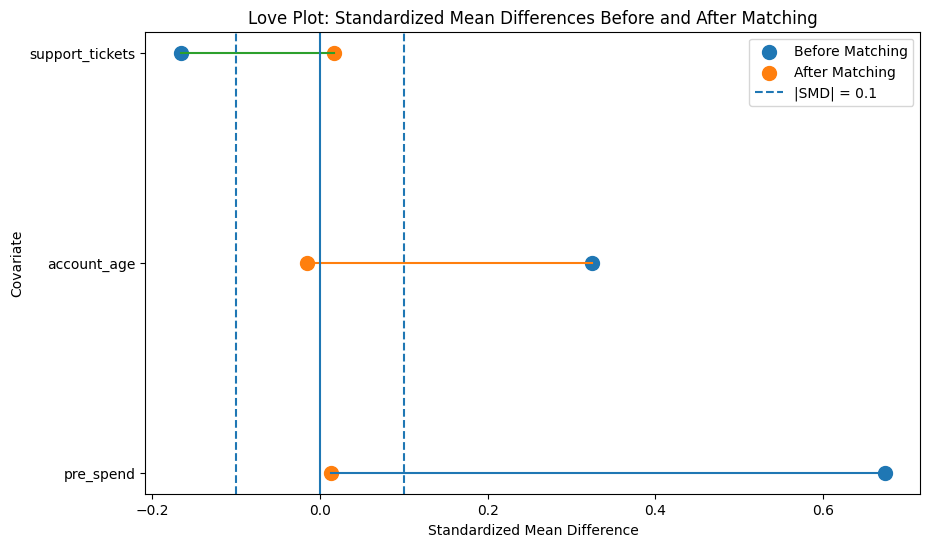

In [ ]:
plt.figure(figsize=(10, 6))


plt.scatter(love_plot_df["Before Matching"], love_plot_df["Covariate"], s=100, label="Before Matching")


plt.scatter(love_plot_df["After Matching"], love_plot_df["Covariate"], s=100, label="After Matching")


for i in range(len(love_plot_df)):
    plt.plot(
        [love_plot_df["Before Matching"][i], love_plot_df["After Matching"][i]],
        [love_plot_df["Covariate"][i], love_plot_df["Covariate"][i]]
    )

plt.axvline(0, linestyle='-')
plt.axvline(0.1, linestyle='--', label='|SMD| = 0.1')
plt.axvline(-0.1, linestyle='--')

plt.title("Love Plot: Standardized Mean Differences Before and After Matching")
plt.xlabel("Standardized Mean Difference")
plt.ylabel("Covariate")
plt.legend()
plt.show()